In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("Tesla.csv")  # change file name if needed
df.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


In [5]:
df.columns = df.columns.str.strip().str.lower()
print(df.columns)

Index(['date', 'open', 'high', 'low', 'close', 'volume', 'adj close'], dtype='object')


In [9]:
df.bfill(inplace=True)

In [11]:
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])
    df['year'] = df['date'].dt.year
    df['month'] = df['date'].dt.month
    df['day'] = df['date'].dt.day
    df.drop(columns=['date'], inplace=True)

In [13]:
print(df.columns)

Index(['open', 'high', 'low', 'close', 'volume', 'adj close', 'year', 'month',
       'day'],
      dtype='object')


In [15]:
target_col = "close"   # OR 'price'

In [17]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train,
y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(" Model trained successfully")

 Model trained successfully


In [25]:
y_pred = model.predict(X_test)

In [31]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

# Predict correctly
y_pred = model.predict(X_test)

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Lengths:", len(y_test), len(y_pred))  # should be SAME

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2:", r2)

Lengths: 339 339
MAE: 5.412910369027902e-14
MSE: 8.407107080109012e-27
R2: 1.0


In [35]:
from sklearn.model_selection import train_test_split

# Make sure X and y are correct
X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [37]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model trained")

✅ Model trained


In [39]:
# ONLY use X_test
y_pred = model.predict(X_test)

print("y_test length:", len(y_test))
print("y_pred length:", len(y_pred))

y_test length: 339
y_pred length: 339


In [41]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 5.412910369027902e-14
MSE: 8.407107080109012e-27
R2 Score: 1.0


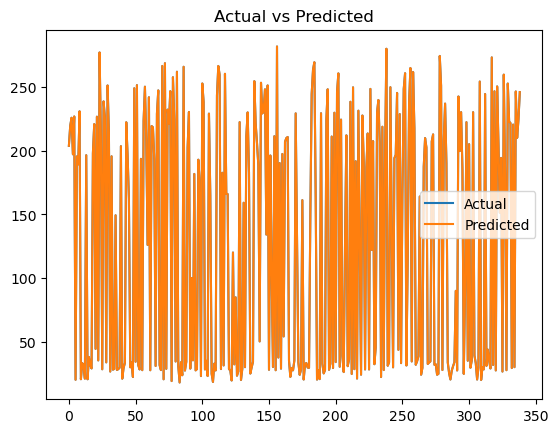

In [43]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted")
plt.show()

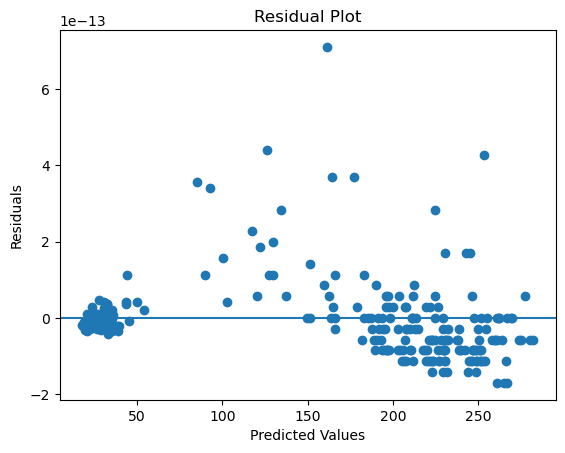

In [45]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

In [47]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("New R2:", r2_score(y_test, y_pred))

New R2: 0.9999792838523887
